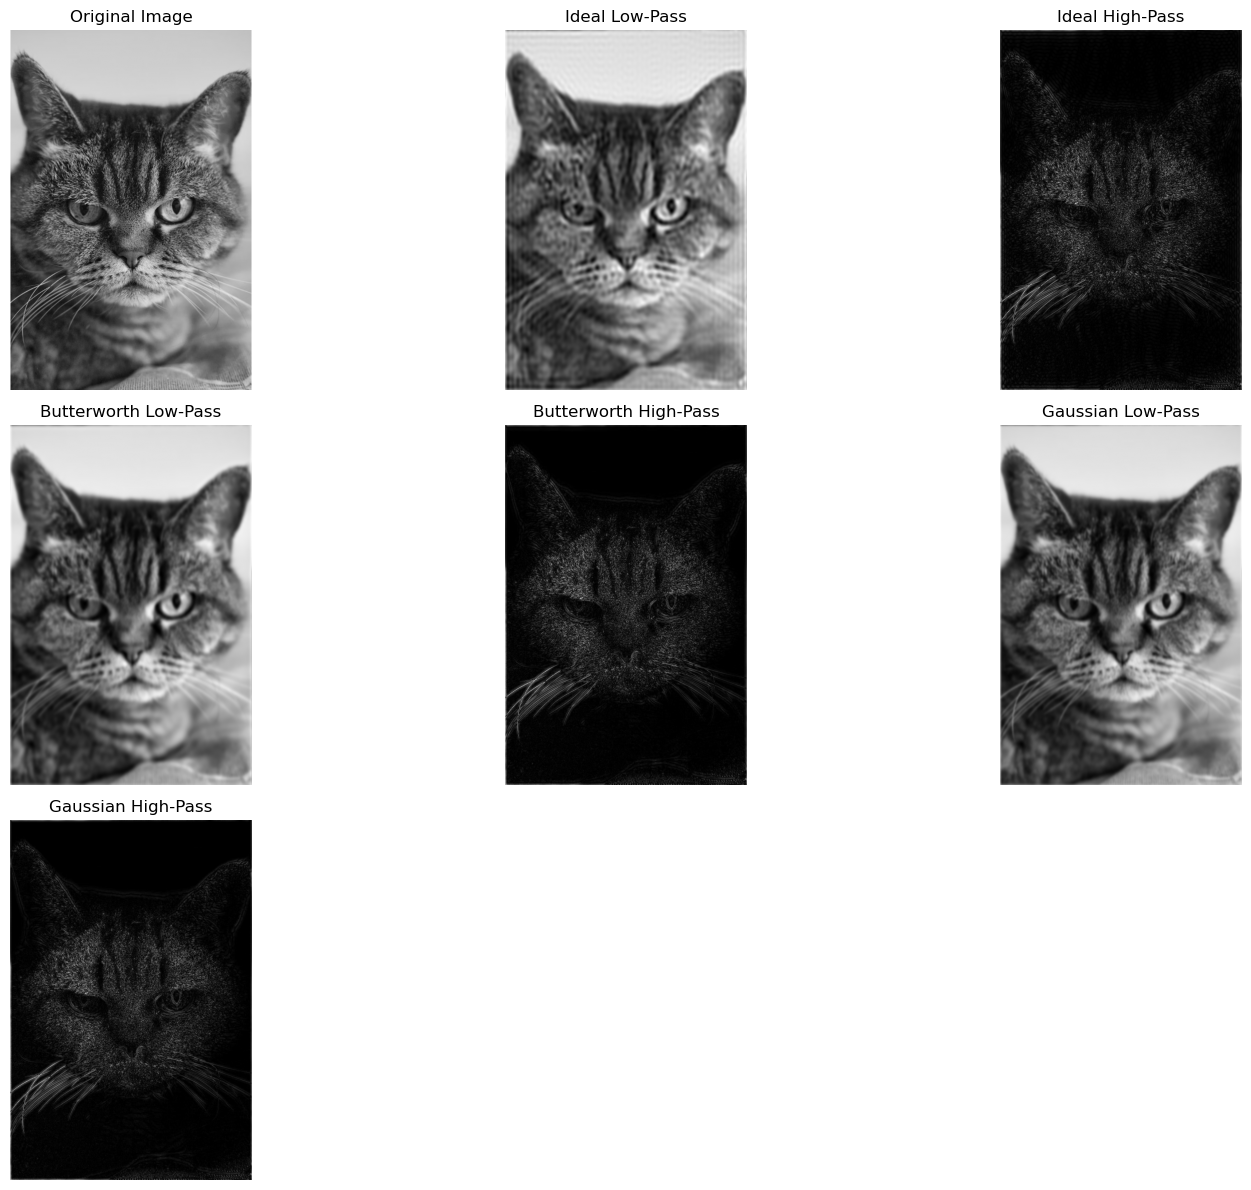

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png", 0)

# Convert image to float
img = np.float32(image)

# Get image dimensions
rows, cols = img.shape

# Find center of frequency domain
crow = rows // 2
ccol = cols // 2

# Fourier Transform

# Apply 2D Fourier Transform
dft = np.fft.fft2(img)

# Shift zero frequency to the center
dft_shift = np.fft.fftshift(dft)

# Create Frequency Grid
u = np.arange(cols)
v = np.arange(rows)

U, V = np.meshgrid(u, v)

# Distance from the center
D = np.sqrt(
    (U - ccol) ** 2 +
    (V - crow) ** 2
)


# Filter Parameters
D0 = 50       # Cutoff frequency
n = 2         # Butterworth filter order


# 1. IDEAL LOW-PASS FILTER
ILPF = np.zeros((rows, cols))

ILPF[D <= D0] = 1

# Apply filter
ideal_low = dft_shift * ILPF

# Inverse Fourier Transform
ideal_low_image = np.fft.ifft2(
    np.fft.ifftshift(ideal_low)
)

ideal_low_image = np.abs(ideal_low_image)

# Normalize
ideal_low_image = cv2.normalize(
    ideal_low_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


# 2. IDEAL HIGH-PASS FILTER
IHPF = np.ones((rows, cols))

IHPF[D <= D0] = 0

ideal_high = dft_shift * IHPF

ideal_high_image = np.fft.ifft2(
    np.fft.ifftshift(ideal_high)
)

ideal_high_image = np.abs(ideal_high_image)

ideal_high_image = cv2.normalize(
    ideal_high_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# 3. BUTTERWORTH LOW-PASS FILTER
BLPF = 1 / (
    1 + (D / D0) ** (2 * n)
)

butter_low = dft_shift * BLPF

butter_low_image = np.fft.ifft2(
    np.fft.ifftshift(butter_low)
)

butter_low_image = np.abs(butter_low_image)

butter_low_image = cv2.normalize(
    butter_low_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


# 4. BUTTERWORTH HIGH-PASS FILTER
BHPF = 1 - BLPF

butter_high = dft_shift * BHPF

butter_high_image = np.fft.ifft2(
    np.fft.ifftshift(butter_high)
)

butter_high_image = np.abs(butter_high_image)

butter_high_image = cv2.normalize(
    butter_high_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


# 5. GAUSSIAN LOW-PASS FILTER
GLPF = np.exp(
    -(D ** 2) / (2 * (D0 ** 2))
)

gaussian_low = dft_shift * GLPF

gaussian_low_image = np.fft.ifft2(
    np.fft.ifftshift(gaussian_low)
)

gaussian_low_image = np.abs(gaussian_low_image)

gaussian_low_image = cv2.normalize(
    gaussian_low_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# 6. GAUSSIAN HIGH-PASS FILTER
GHPF = 1 - GLPF

gaussian_high = dft_shift * GHPF

gaussian_high_image = np.fft.ifft2(
    np.fft.ifftshift(gaussian_high)
)

gaussian_high_image = np.abs(gaussian_high_image)

gaussian_high_image = cv2.normalize(
    gaussian_high_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


# Display Results
plt.figure(figsize=(15, 12))

# Original
plt.subplot(3, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Ideal LPF
plt.subplot(3, 3, 2)
plt.imshow(ideal_low_image, cmap="gray")
plt.title("Ideal Low-Pass")
plt.axis("off")

# Ideal HPF
plt.subplot(3, 3, 3)
plt.imshow(ideal_high_image, cmap="gray")
plt.title("Ideal High-Pass")
plt.axis("off")

# Butterworth LPF
plt.subplot(3, 3, 4)
plt.imshow(butter_low_image, cmap="gray")
plt.title("Butterworth Low-Pass")
plt.axis("off")

# Butterworth HPF
plt.subplot(3, 3, 5)
plt.imshow(butter_high_image, cmap="gray")
plt.title("Butterworth High-Pass")
plt.axis("off")

# Gaussian LPF
plt.subplot(3, 3, 6)
plt.imshow(gaussian_low_image, cmap="gray")
plt.title("Gaussian Low-Pass")
plt.axis("off")

# Gaussian HPF
plt.subplot(3, 3, 7)
plt.imshow(gaussian_high_image, cmap="gray")
plt.title("Gaussian High-Pass")
plt.axis("off")

plt.tight_layout()
plt.show()

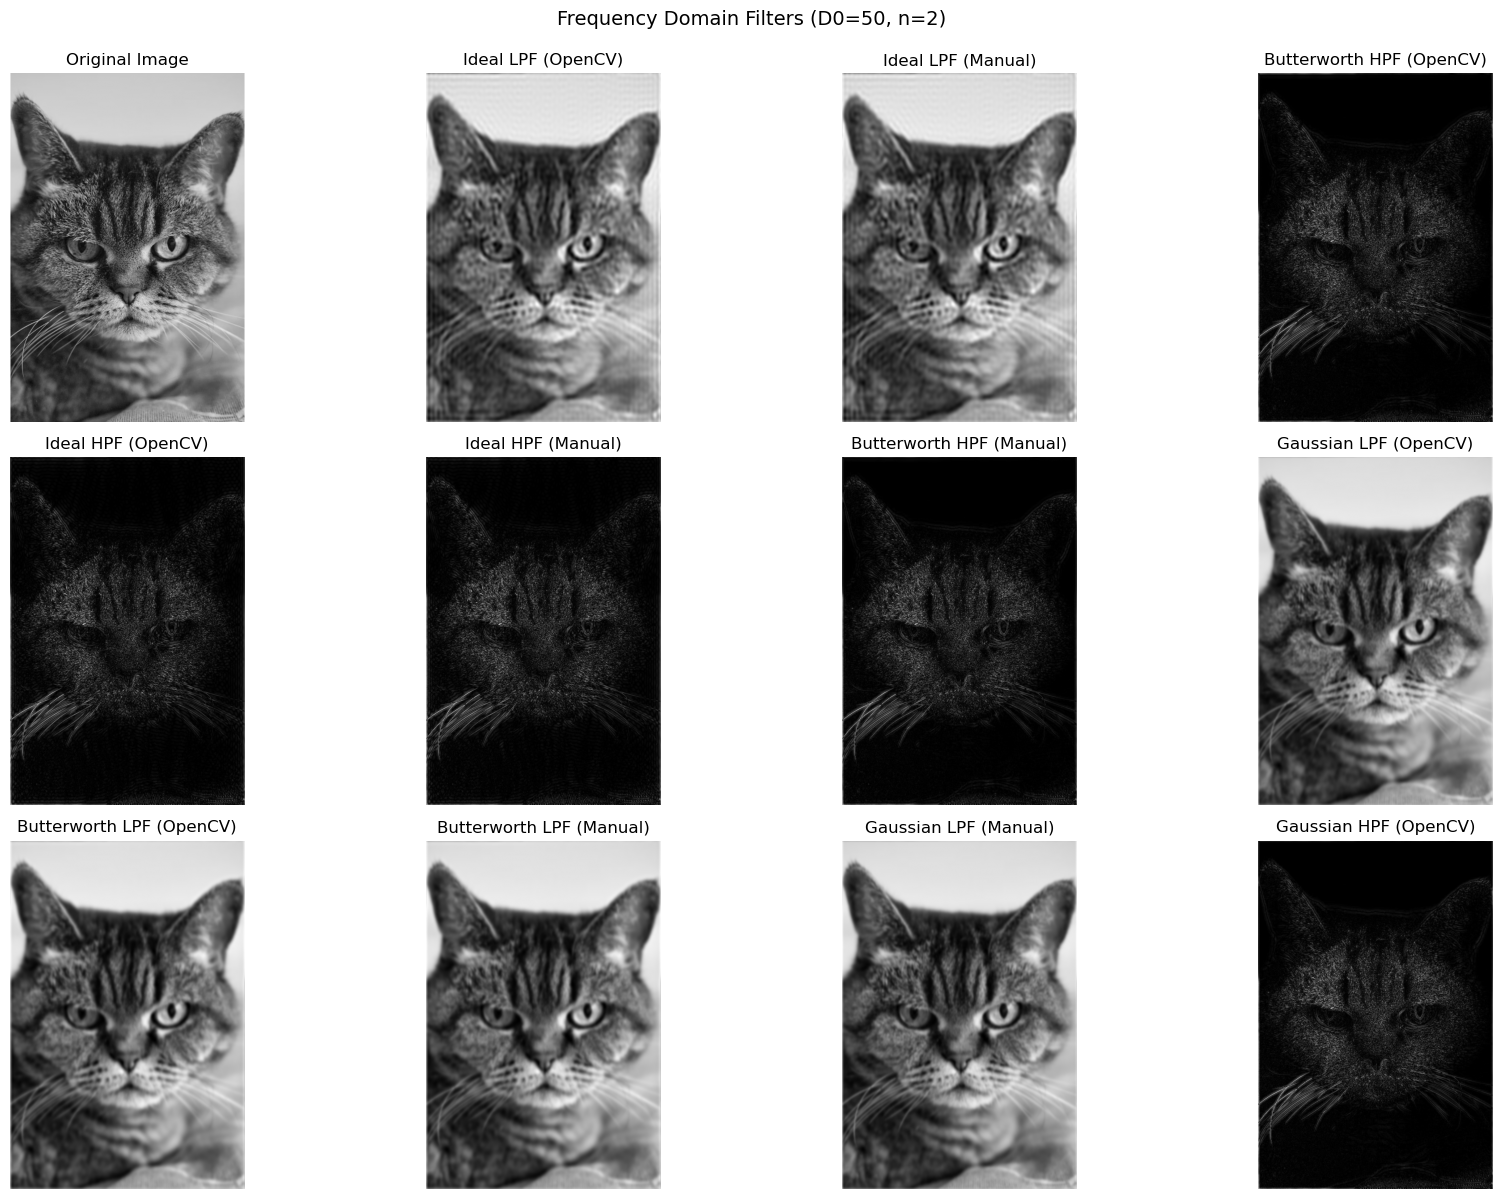

In [2]:
# Manual Normalization Function
def manual_normalize(image, min_val=0, max_val=255):
    """Normalize image values manually"""
    img_min = np.min(image)
    img_max = np.max(image)
    
    if img_max == img_min:
        return np.full_like(image, max_val, dtype=np.uint8)
    
    normalized = (image - img_min) / (img_max - img_min)
    normalized = normalized * (max_val - min_val) + min_val
    
    return normalized.astype(np.uint8)


# Manual Inverse FFT and Processing Function
def manual_process_filter(filtered_dft, rows, cols):
    """Apply inverse FFT and normalize manually"""
    # Inverse shift
    ifft_shift = np.fft.ifftshift(filtered_dft)
    
    # Inverse FFT
    inverse_fft = np.fft.ifft2(ifft_shift)
    
    # Get magnitude
    magnitude = np.abs(inverse_fft)
    
    # Normalize manually
    normalized = manual_normalize(magnitude, 0, 255)
    
    return normalized


# Re-compute all filters with manual processing

# 1. IDEAL LOW-PASS FILTER (Manual)
ILPF_manual = np.zeros((rows, cols))
ILPF_manual[D <= D0] = 1

ideal_low_manual = dft_shift * ILPF_manual
ideal_low_image_manual = manual_process_filter(ideal_low_manual, rows, cols)


# 2. IDEAL HIGH-PASS FILTER (Manual)
IHPF_manual = np.ones((rows, cols))
IHPF_manual[D <= D0] = 0

ideal_high_manual = dft_shift * IHPF_manual
ideal_high_image_manual = manual_process_filter(ideal_high_manual, rows, cols)


# 3. BUTTERWORTH LOW-PASS FILTER (Manual)
BLPF_manual = 1 / (1 + (D / D0) ** (2 * n))

butter_low_manual = dft_shift * BLPF_manual
butter_low_image_manual = manual_process_filter(butter_low_manual, rows, cols)


# 4. BUTTERWORTH HIGH-PASS FILTER (Manual)
BHPF_manual = 1 - BLPF_manual

butter_high_manual = dft_shift * BHPF_manual
butter_high_image_manual = manual_process_filter(butter_high_manual, rows, cols)


# 5. GAUSSIAN LOW-PASS FILTER (Manual)
GLPF_manual = np.exp(-(D ** 2) / (2 * (D0 ** 2)))

gaussian_low_manual = dft_shift * GLPF_manual
gaussian_low_image_manual = manual_process_filter(gaussian_low_manual, rows, cols)


# 6. GAUSSIAN HIGH-PASS FILTER (Manual)
GHPF_manual = 1 - GLPF_manual

gaussian_high_manual = dft_shift * GHPF_manual
gaussian_high_image_manual = manual_process_filter(gaussian_high_manual, rows, cols)


# Display Comparison: OpenCV normalize vs Manual normalize
plt.figure(figsize=(18, 12))

# Original
plt.subplot(3, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Ideal LPF - OpenCV
plt.subplot(3, 4, 2)
plt.imshow(ideal_low_image, cmap="gray")
plt.title("Ideal LPF (OpenCV)")
plt.axis("off")

# Ideal LPF - Manual
plt.subplot(3, 4, 3)
plt.imshow(ideal_low_image_manual, cmap="gray")
plt.title("Ideal LPF (Manual)")
plt.axis("off")

# Ideal HPF - OpenCV
plt.subplot(3, 4, 5)
plt.imshow(ideal_high_image, cmap="gray")
plt.title("Ideal HPF (OpenCV)")
plt.axis("off")

# Ideal HPF - Manual
plt.subplot(3, 4, 6)
plt.imshow(ideal_high_image_manual, cmap="gray")
plt.title("Ideal HPF (Manual)")
plt.axis("off")

# Butterworth LPF - OpenCV
plt.subplot(3, 4, 9)
plt.imshow(butter_low_image, cmap="gray")
plt.title("Butterworth LPF (OpenCV)")
plt.axis("off")

# Butterworth LPF - Manual
plt.subplot(3, 4, 10)
plt.imshow(butter_low_image_manual, cmap="gray")
plt.title("Butterworth LPF (Manual)")
plt.axis("off")

# Butterworth HPF - OpenCV
plt.subplot(3, 4, 4)
plt.imshow(butter_high_image, cmap="gray")
plt.title("Butterworth HPF (OpenCV)")
plt.axis("off")

# Butterworth HPF - Manual
plt.subplot(3, 4, 7)
plt.imshow(butter_high_image_manual, cmap="gray")
plt.title("Butterworth HPF (Manual)")
plt.axis("off")

# Gaussian LPF - OpenCV
plt.subplot(3, 4, 8)
plt.imshow(gaussian_low_image, cmap="gray")
plt.title("Gaussian LPF (OpenCV)")
plt.axis("off")

# Gaussian LPF - Manual
plt.subplot(3, 4, 11)
plt.imshow(gaussian_low_image_manual, cmap="gray")
plt.title("Gaussian LPF (Manual)")
plt.axis("off")

# Gaussian HPF - OpenCV
plt.subplot(3, 4, 12)
plt.imshow(gaussian_high_image, cmap="gray")
plt.title("Gaussian HPF (OpenCV)")
plt.axis("off")

plt.suptitle(f"Frequency Domain Filters (D0={D0}, n={n})", fontsize=14, y=0.995)
plt.tight_layout()
plt.show()